In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Libraries and dependencies 

In [1]:
!pip install einops -q

In [2]:
import os, csv, math, random, shutil, zipfile
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
from torchvision import transforms, datasets

from einops import rearrange
from skimage.metrics import peak_signal_noise_ratio as psnr_metric
from skimage.metrics import structural_similarity  as ssim_metric

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device        : {device}')
print(f'GPUs available: {torch.cuda.device_count()}')
for i in range(torch.cuda.device_count()):
    print(f'  GPU {i}: {torch.cuda.get_device_name(i)}')

Device        : cuda
GPUs available: 2
  GPU 0: Tesla T4
  GPU 1: Tesla T4


# Hyper-params

In [3]:
CFG = {
    # Image / Patch
    "img_size":      224,
    "patch_size":    16,
    "in_channels":   3,

    # Masking
    "mask_ratio":    0.75,        # 75% patches masked

    # Encoder — ViT-Base (B/16) ~86M params
    "enc_dim":       768,
    "enc_depth":     12,
    "enc_heads":     12,
    "enc_mlp_ratio": 4.0,

    # Decoder — ViT-Small (S/16) ~22M params
    "dec_dim":       384,
    "dec_depth":     12,
    "dec_heads":     6,
    "dec_mlp_ratio": 4.0,

    # Training
    "epochs":        40,
    "batch_size":    64,      
    "lr":            1.5e-4,
    "weight_decay":  0.05,
    "warmup_epochs": 10,
    "grad_clip":     1.0,

    # Data
    "data_dir": "/kaggle/input/datasets/akash2sharma/tiny-imagenet/tiny-imagenet-200",
    "num_workers": 4,
}

# Derived constants
NUM_PATCHES = (CFG["img_size"] // CFG["patch_size"]) ** 2   # 196
NUM_VISIBLE = int(NUM_PATCHES * (1 - CFG["mask_ratio"]))    # 49
NUM_MASKED  = NUM_PATCHES - NUM_VISIBLE                     # 147

print(f"Total patches : {NUM_PATCHES}")
print(f"Visible (25%) : {NUM_VISIBLE}")
print(f"Masked  (75%) : {NUM_MASKED}")


Total patches : 196
Visible (25%) : 49
Masked  (75%) : 147


# Dataset & Dataloaders

In [4]:
def fix_val_folder(val_dir):
    img_dir   = os.path.join(val_dir, "images")
    anno_file = os.path.join(val_dir, "val_annotations.txt")
    work_val  = "/kaggle/working/val_organised"

    if os.path.isdir(work_val):
        print("val/ already organised — skipping.")
        return work_val

    print("Reorganising val/ ...", end=" ")
    with open(anno_file) as f:
        for line in f:
            parts = line.strip().split("\t")
            fname, cls = parts[0], parts[1]
            dst_dir = os.path.join(work_val, cls)
            os.makedirs(dst_dir, exist_ok=True)
            src = os.path.join(img_dir, fname)
            dst = os.path.join(dst_dir, fname)
            if os.path.isfile(src):
                shutil.copy2(src, dst)   # copy instead of move (input is read-only)
    print("done.")
    return work_val

val_dir = fix_val_folder(os.path.join(CFG["data_dir"], "val"))

train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225]),
])

train_dataset = datasets.ImageFolder(
    os.path.join(CFG["data_dir"], "train"), transform=train_transform)
val_dataset   = datasets.ImageFolder(
    val_dir, transform=val_transform)          # ← uses reorganised copy

train_loader = DataLoader(
    train_dataset,
    batch_size  = CFG["batch_size"],
    shuffle     = True,
    num_workers = CFG["num_workers"],
    pin_memory  = True,
    drop_last   = True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size  = CFG["batch_size"],
    shuffle     = False,
    num_workers = CFG["num_workers"],
    pin_memory  = True,
)

print(f"Train samples : {len(train_dataset)}")
print(f"Val   samples : {len(val_dataset)}")
print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

Reorganising val/ ... done.
Train samples : 100000
Val   samples : 10000
Train batches : 1562
Val   batches : 157


# Building blocks

In [5]:
class PatchEmbed(nn.Module):
    
    def __init__(self, img_size, patch_size, in_ch, embed_dim):
        super().__init__()
        self.num_patches = (img_size // patch_size) ** 2
        self.patch_size  = patch_size
        self.proj = nn.Conv2d(
            in_ch, embed_dim,
            kernel_size=patch_size,
            stride=patch_size
        )

    def forward(self, x):
        x = self.proj(x)       # (B, embed_dim, H/P, W/P)
        x = x.flatten(2)       # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)  # (B, num_patches, embed_dim)
        return x


class MultiHeadSelfAttention(nn.Module):
    """
    Standard scaled dot-product multi-head self-attention.
    Scale = 1/sqrt(head_dim) prevents softmax saturation.
    """
    def __init__(self, dim, num_heads, dropout=0.0):
        super().__init__()
        assert dim % num_heads == 0, "dim must be divisible by num_heads"
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5

        self.qkv  = nn.Linear(dim, dim * 3, bias=True)
        self.proj = nn.Linear(dim, dim)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        B, N, C = x.shape
        # Single projection → split into Q, K, V
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)     # (3, B, heads, N, head_dim)
        q, k, v = qkv.unbind(0)

        attn = (q @ k.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)
        attn = self.drop(attn)

        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        return self.proj(x)


class MLP(nn.Module):
    """
    Two-layer feed-forward network with GELU activation.
    Hidden dim = embed_dim × mlp_ratio (typically 4×).
    """
    def __init__(self, dim, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        hidden = int(dim * mlp_ratio)
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, dim),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)


class TransformerBlock(nn.Module):
    """
    One Transformer block with Pre-LayerNorm (more stable than post-norm).
    x → LN → Attention → residual → LN → MLP → residual
    """
    def __init__(self, dim, num_heads, mlp_ratio=4.0, dropout=0.0):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn  = MultiHeadSelfAttention(dim, num_heads, dropout)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp   = MLP(dim, mlp_ratio, dropout)

    def forward(self, x):
        x = x + self.attn(self.norm1(x))   # attention  + residual
        x = x + self.mlp(self.norm2(x))    # feed-fwd   + residual
        return x

# MAE encoder

In [6]:
class MAEEncoder(nn.Module):
    
    def __init__(self, img_size, patch_size, in_ch,
                 embed_dim, depth, num_heads, mlp_ratio):
        super().__init__()
        num_patches = (img_size // patch_size) ** 2

        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)

        # CLS token — learnable global representation
        self.cls_token = nn.Parameter(torch.zeros(1, 1, embed_dim))

        # Fixed sinusoidal positional embeddings (not learned)
        # Shape: (1, num_patches+1, embed_dim) — +1 for CLS
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, embed_dim),
            requires_grad=False
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(embed_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(embed_dim)

        self._init_weights()

    def _init_weights(self):
        # Build fixed sinusoidal positional encoding
        pos = self._build_sinusoidal_pos_embed(
            self.pos_embed.shape[-2],
            self.pos_embed.shape[-1]
        )
        self.pos_embed.data.copy_(pos)
        nn.init.normal_(self.cls_token, std=0.02)

    @staticmethod
    def _build_sinusoidal_pos_embed(num_pos, dim):
        """
        Standard sine/cosine positional encoding.
        Even indices → sin, Odd indices → cos
        """
        pos = torch.arange(num_pos).unsqueeze(1).float()
        div = torch.exp(
            torch.arange(0, dim, 2).float() * -(math.log(10000.0) / dim)
        )
        enc = torch.zeros(num_pos, dim)
        enc[:, 0::2] = torch.sin(pos * div)
        enc[:, 1::2] = torch.cos(pos * div)
        return enc.unsqueeze(0)   # (1, num_pos, dim)

    def random_masking(self, x, mask_ratio):
        
        B, N, D  = x.shape
        num_keep = int(N * (1 - mask_ratio))   # 49 visible patches

        # Random permutation
        noise       = torch.rand(B, N, device=x.device)
        ids_shuffle = torch.argsort(noise, dim=1)
        ids_restore = torch.argsort(ids_shuffle, dim=1)  # inverse permutation

        # Keep first num_keep
        ids_keep  = ids_shuffle[:, :num_keep]
        x_visible = torch.gather(
            x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D)
        )

        # Binary mask in ORIGINAL patch order
        mask = torch.ones(B, N, device=x.device)
        mask[:, :num_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_visible, mask, ids_restore

    def forward(self, x, mask_ratio=0.75):
        # Step 1: Embed all patches
        x = self.patch_embed(x)                    # (B, N, D)

        # Step 2: Add positional embeddings to patches (skip CLS slot [0])
        x = x + self.pos_embed[:, 1:, :]

        # Step 3: Random masking — keep only 25% visible patches
        x_vis, mask, ids_restore = self.random_masking(x, mask_ratio)

        # Step 4: Prepend CLS token with positional embedding
        cls   = self.cls_token.expand(x_vis.shape[0], -1, -1)
        cls   = cls + self.pos_embed[:, :1, :]
        x_vis = torch.cat([cls, x_vis], dim=1)     # (B, 1+num_keep, D)

        # Step 5: Transformer encoder — processes ONLY visible patches
        x_vis = self.blocks(x_vis)
        x_vis = self.norm(x_vis)

        return x_vis, mask, ids_restore

# MAE decoder

In [7]:
class MAEDecoder(nn.Module):
    
    def __init__(self, num_patches, patch_size, in_ch,
                 encoder_dim, decoder_dim, depth, num_heads, mlp_ratio):
        super().__init__()

        # Project encoder dim → decoder dim
        self.enc_to_dec = nn.Linear(encoder_dim, decoder_dim, bias=True)

        # Shared learnable mask token — replaces all masked patch positions
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        # Fixed sinusoidal positional embeddings for decoder
        self.pos_embed = nn.Parameter(
            torch.zeros(1, num_patches + 1, decoder_dim),
            requires_grad=False
        )

        self.blocks = nn.Sequential(*[
            TransformerBlock(decoder_dim, num_heads, mlp_ratio)
            for _ in range(depth)
        ])
        self.norm = nn.LayerNorm(decoder_dim)

        # Pixel reconstruction head
        # Each patch = patch_size × patch_size × 3 channels = 768 values
        patch_dim  = in_ch * patch_size * patch_size
        self.head  = nn.Linear(decoder_dim, patch_dim, bias=True)

        self._init_weights()

    def _init_weights(self):
        pos = MAEEncoder._build_sinusoidal_pos_embed(
            self.pos_embed.shape[-2],
            self.pos_embed.shape[-1]
        )
        self.pos_embed.data.copy_(pos)
        nn.init.normal_(self.mask_token, std=0.02)

    def forward(self, x_enc, ids_restore):
        """
        x_enc      : (B, 1+num_visible, encoder_dim)
        ids_restore: (B, N) — inverse permutation to restore spatial order
        """
        # Step 1: Project encoder output to decoder dimension
        x = self.enc_to_dec(x_enc)              # (B, 1+num_vis, dec_dim)

        # Step 2: Build mask tokens for masked positions
        N_full      = ids_restore.shape[1]       # 196 total patches
        num_vis     = x.shape[1] - 1             # subtract CLS token
        num_masked  = N_full - num_vis           # 147 masked patches

        mask_tokens = self.mask_token.expand(
            x.shape[0], num_masked, -1
        )                                        # (B, 147, dec_dim)

        # Step 3: Concatenate visible tokens + mask tokens (no CLS yet)
        x_no_cls = x[:, 1:, :]                  # (B, num_vis, dec_dim)
        x_full   = torch.cat([x_no_cls, mask_tokens], dim=1)  # (B, N, dec_dim)

        # Step 4: Restore original spatial order using ids_restore
        # This puts each patch back in its correct position (0..195)
        x_full = torch.gather(
            x_full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, x_full.shape[-1])
        )

        # Step 5: Add decoder positional embeddings
        x_full = x_full + self.pos_embed[:, 1:, :]

        # Step 6: Re-prepend CLS token
        cls    = x[:, :1, :] + self.pos_embed[:, :1, :]
        x_full = torch.cat([cls, x_full], dim=1)

        # Step 7: Lightweight transformer
        x_full = self.blocks(x_full)
        x_full = self.norm(x_full)

        # Step 8: Project to pixel space — drop CLS output
        pred = self.head(x_full[:, 1:, :])       # (B, N, patch_dim)
        return pred

# MAE model

In [8]:
class MAE(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        num_patches     = (cfg['img_size'] // cfg['patch_size']) ** 2
        self.patch_size = cfg['patch_size']
        self.encoder = MAEEncoder(
            img_size=cfg['img_size'],  patch_size=cfg['patch_size'],
            in_ch=cfg['in_channels'],  embed_dim=cfg['enc_dim'],
            depth=cfg['enc_depth'],    num_heads=cfg['enc_heads'],
            mlp_ratio=cfg['enc_mlp_ratio'],
        )
        self.decoder = MAEDecoder(
            num_patches=num_patches,   patch_size=cfg['patch_size'],
            in_ch=cfg['in_channels'],  encoder_dim=cfg['enc_dim'],
            decoder_dim=cfg['dec_dim'],depth=cfg['dec_depth'],
            num_heads=cfg['dec_heads'],mlp_ratio=cfg['dec_mlp_ratio'],
        )

    def patchify(self, imgs):
        """(B,C,H,W) -> (B, N, C*p*p)"""
        p = self.patch_size
        B, C, H, W = imgs.shape
        h = w = H // p
        x = imgs.reshape(B, C, h, p, w, p).permute(0, 2, 4, 1, 3, 5)
        return x.reshape(B, h * w, C * p * p)

    def unpatchify(self, x):
        """(B, N, C*p*p) -> (B,C,H,W)"""
        p = self.patch_size
        B, N, _ = x.shape
        h = w = int(N ** 0.5)
        x = x.reshape(B, h, w, 3, p, p).permute(0, 3, 1, 4, 2, 5)
        return x.reshape(B, 3, h * p, w * p)

    def forward(self, imgs, mask_ratio=0.75):
        latent, mask, ids_restore = self.encoder(imgs, mask_ratio)
        pred   = self.decoder(latent, ids_restore)    # (B, N, patch_dim)
        target = self.patchify(imgs)                   # (B, N, patch_dim)

        loss = (pred - target) ** 2                    # (B, N, patch_dim)
        loss = loss.mean(dim=-1)                       # (B, N)
        # ✅ FIX: return (B,) so DataParallel can gather across GPUs
        loss = (loss * mask).sum(dim=-1) / mask.sum(dim=-1)   # (B,)
        return loss, pred, mask


# Build & optionally wrap with DataParallel
model = MAE(CFG)
if torch.cuda.device_count() > 1:
    print(f'Using {torch.cuda.device_count()} GPUs -> nn.DataParallel')
    model = nn.DataParallel(model)
model = model.to(device)

# Parameter count
raw = model.module if hasattr(model, 'module') else model
ep  = sum(p.numel() for p in raw.encoder.parameters()) / 1e6
dp  = sum(p.numel() for p in raw.decoder.parameters()) / 1e6
print(f'Encoder params : {ep:.1f}M  (target ~86M)')
print(f'Decoder params : {dp:.1f}M  (target ~22M)')
print(f'Total params   : {ep+dp:.1f}M')

Using 2 GPUs -> nn.DataParallel
Encoder params : 85.8M  (target ~86M)
Decoder params : 22.0M  (target ~22M)
Total params   : 107.8M


# optimizer 

In [9]:
raw_model = model.module if hasattr(model, "module") else model

decay_params    = []
no_decay_params = []

for name, param in raw_model.named_parameters():
    if not param.requires_grad:
        continue
    if param.ndim < 2 or "norm" in name or "bias" in name:
        no_decay_params.append(param)
    else:
        decay_params.append(param)

optimizer = torch.optim.AdamW(
    [
        {"params": decay_params,    "weight_decay": CFG["weight_decay"]},
        {"params": no_decay_params, "weight_decay": 0.0},
    ],
    lr    = CFG["lr"],
    betas = (0.9, 0.95),
)

# ── Cosine LR with linear warmup ────────────────────────────
def cosine_lr_with_warmup(optimizer, warmup_epochs, total_epochs):
    def lr_lambda(epoch):
        if epoch < warmup_epochs:
            return float(epoch) / float(max(1, warmup_epochs))
        progress = float(epoch - warmup_epochs) / float(
            max(1, total_epochs - warmup_epochs))
        return 0.5 * (1.0 + math.cos(math.pi * progress))
    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

scheduler = cosine_lr_with_warmup(
    optimizer,
    CFG["warmup_epochs"],
    CFG["epochs"]
)

scaler = torch.amp.GradScaler("cuda")

# ── Early Stopping Config ───────────────────────────────────
EARLY_STOP_PATIENCE = 8      # stop if no improvement for 15 epochs
EARLY_STOP_MIN_DELTA = 1e-5   # minimum improvement to count as better
VISUALIZE_EVERY     = 8       # show reconstruction output every N epochs

print("✅ Optimizer  : AdamW  (betas=0.9, 0.95  |  wd=0.05)")
print("✅ Scheduler  : Cosine LR with linear warmup")
print(f"   Warmup     : {CFG['warmup_epochs']} epochs")
print(f"   Total      : {CFG['epochs']} epochs")
print("✅ AMP Scaler : GradScaler ready")
print(f"✅ Early Stop : patience={EARLY_STOP_PATIENCE}  "
      f"min_delta={EARLY_STOP_MIN_DELTA}")
print(f"✅ Visualize  : every {VISUALIZE_EVERY} epochs")

✅ Optimizer  : AdamW  (betas=0.9, 0.95  |  wd=0.05)
✅ Scheduler  : Cosine LR with linear warmup
   Warmup     : 10 epochs
   Total      : 40 epochs
✅ AMP Scaler : GradScaler ready
✅ Early Stop : patience=8  min_delta=1e-05
✅ Visualize  : every 8 epochs


# training loop

                    MAE TRAINING STARTED
  Max Epochs          : 40
  Early Stop          : patience=8, min_delta=1e-05
  Visualize           : every 8 epochs
  Batch per GPU       : 64  →  Effective: 128
  Train Batches       : 1562
  Val Batches         : 157
  Epoch    Train Loss     Val Loss       LR           Status
----------------------------------------------------------------------
  1        1.68091        1.68060        1.50e-05     ✅ BEST                    ss=1.5479
  2        0.68390        0.45954        3.00e-05     ✅ BEST                    ss=0.3754
  3        0.41185        0.36128        4.50e-05     ✅ BEST                    ss=0.2798
  4        0.34581        0.30250        6.00e-05     ✅ BEST                    ss=0.2410
  5        0.30321        0.27821        7.50e-05     ✅ BEST                    ss=0.2206
  6        0.28060        0.25539        9.00e-05     ✅ BEST                    ss=0.2038
  7        0.26180        0.23988        1.05e-04     ✅ BEST      

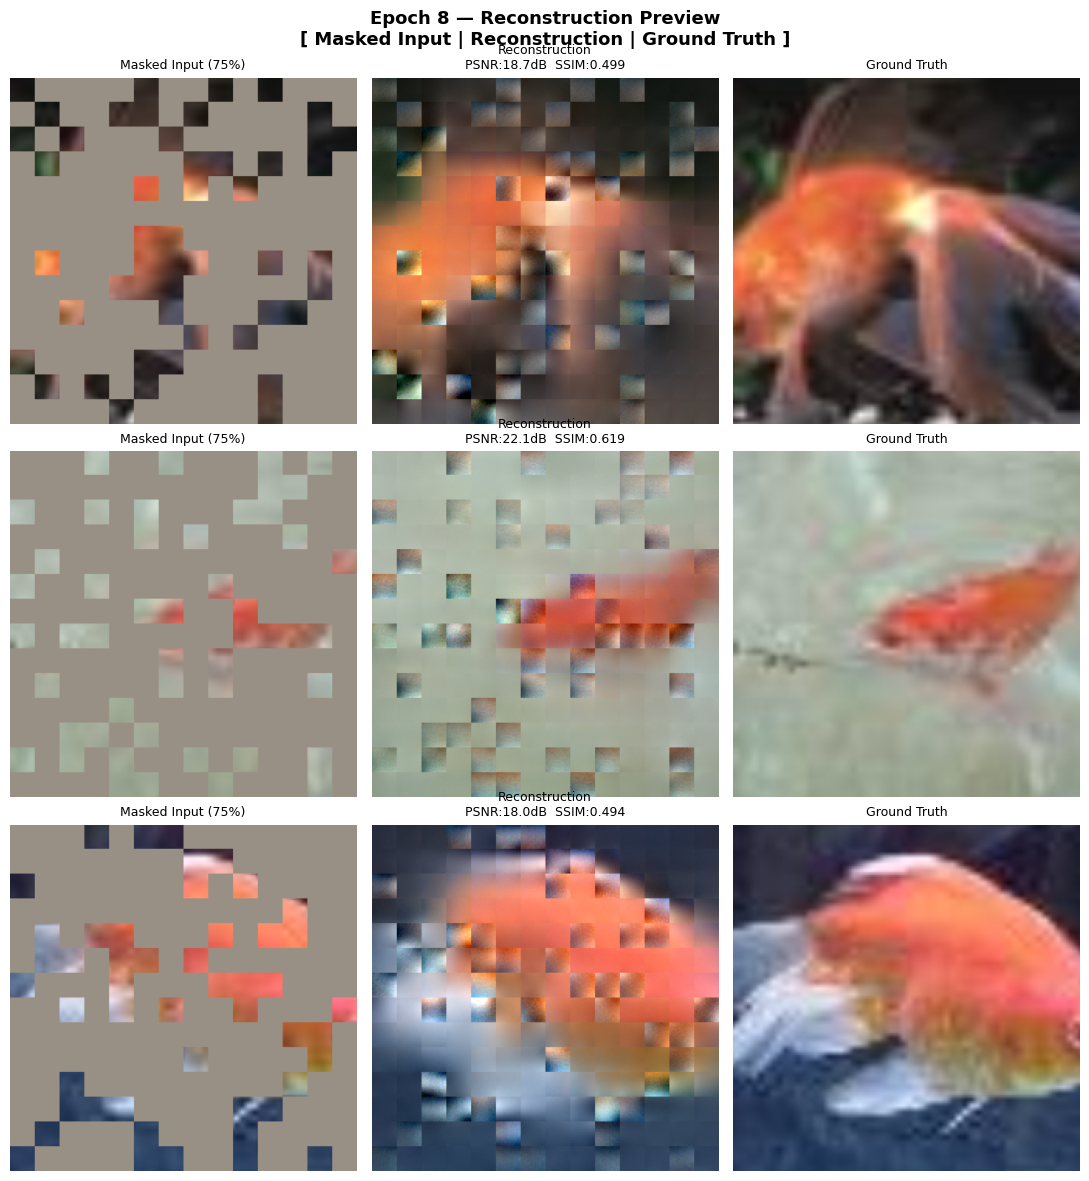

   📸 Preview saved → /kaggle/working/epoch_visuals/epoch_008.png
----------------------------------------------------------------------
  Epoch    Train Loss     Val Loss       LR           Status
----------------------------------------------------------------------
  9        0.24247        0.22450        1.35e-04     ✅ BEST                    ss=0.1708
  10       0.23632        0.21828        1.50e-04     ✅ BEST                    ss=0.1722
  11       0.23088        0.21631        1.50e-04     ✅ BEST                    ss=0.1583
  12       0.22596        0.20897        1.48e-04     ✅ BEST                    ss=0.1715
  13       0.22137        0.20717        1.46e-04     ✅ BEST                    ss=0.1603
  14       0.21738        0.20316        1.44e-04     ✅ BEST                    ss=0.1574
  15       0.21482        0.20199        1.40e-04     ✅ BEST                    ss=0.1520
  16       0.21214        0.19736        1.36e-04     ✅ BEST                    ss=0.1666
------------

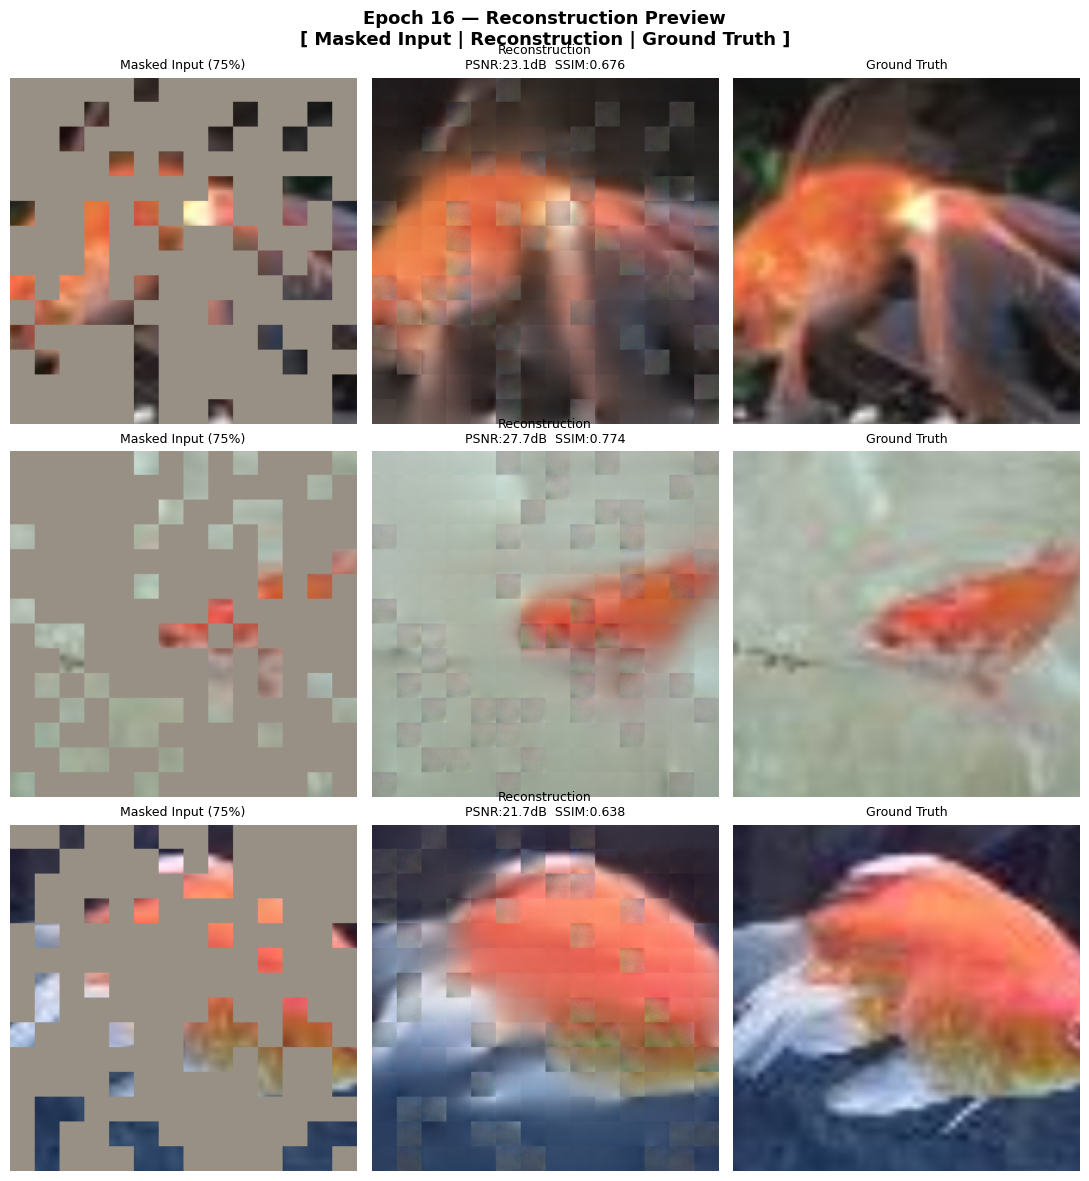

   📸 Preview saved → /kaggle/working/epoch_visuals/epoch_016.png
----------------------------------------------------------------------
  Epoch    Train Loss     Val Loss       LR           Status
----------------------------------------------------------------------
  17       0.21002        0.19532        1.31e-04     ✅ BEST                    ss=0.1586
  Ep 18/40 │ Train:  79%|████████████▋   │ 1235/1562 [07:23<01:56] , loss=0.2114

In [ ]:
# ============================================================
# CELL 9: Full Training Loop with tqdm Progress Bar
# ============================================================

import sys
import warnings
warnings.filterwarnings("ignore")   # ← removes DataParallel warning

from torch.amp import autocast
from tqdm import tqdm

# ── Helper functions for visualization ──────────────────────
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Undo ImageNet normalization → [0, 1]"""
    t = tensor.clone().cpu()
    t = t * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    return t.clamp(0, 1)

def make_masked_image(img_tensor, mask, patch_size=16):
    """Replace masked patches with grey (0.5) for visualization."""
    img     = img_tensor.clone()
    C, H, W = img.shape
    h = w   = H // patch_size
    mask_2d = mask.reshape(h, w)
    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 1:
                img[:, i*patch_size:(i+1)*patch_size,
                       j*patch_size:(j+1)*patch_size] = 0.5
    return img

# ── Fresh scaler ─────────────────────────────────────────────
scaler = torch.amp.GradScaler("cuda")

train_losses  = []
val_losses    = []
best_val_loss = float("inf")
es_counter    = 0
es_stopped    = False

os.makedirs("/kaggle/working", exist_ok=True)
os.makedirs("/kaggle/working/epoch_visuals", exist_ok=True)

# ── Helper: show reconstructions every N epochs ─────────────
def show_epoch_reconstructions(model, val_loader, device,
                                epoch, save_dir, num_samples=3):
    raw = model.module if hasattr(model, "module") else model
    raw.eval()

    imgs_batch, _ = next(iter(val_loader))
    imgs_batch    = imgs_batch[:num_samples].to(device)

    with torch.no_grad():
        with autocast("cuda"):
            _, pred, mask = raw(imgs_batch,
                                mask_ratio=CFG["mask_ratio"])
    recon = raw.unpatchify(pred)

    fig, axes = plt.subplots(num_samples, 3,
                             figsize=(11, 4 * num_samples))
    fig.suptitle(
        f"Epoch {epoch} — Reconstruction Preview\n"
        f"[ Masked Input | Reconstruction | Ground Truth ]",
        fontsize=13, fontweight="bold"
    )

    for i in range(num_samples):
        gt_np    = denormalize(imgs_batch[i].cpu()).permute(1,2,0).numpy()
        mask_img = make_masked_image(imgs_batch[i].cpu(), mask[i].cpu())
        mask_np  = denormalize(mask_img).permute(1,2,0).numpy()
        recon_np = denormalize(recon[i].cpu()).permute(1,2,0).numpy()

        p = psnr_metric(gt_np, recon_np, data_range=1.0)
        s = ssim_metric(gt_np, recon_np, data_range=1.0, channel_axis=2)

        axes[i, 0].imshow(mask_np)
        axes[i, 0].set_title("Masked Input (75%)", fontsize=9)
        axes[i, 0].axis("off")

        axes[i, 1].imshow(recon_np)
        axes[i, 1].set_title(
            f"Reconstruction\nPSNR:{p:.1f}dB  SSIM:{s:.3f}",
            fontsize=9)
        axes[i, 1].axis("off")

        axes[i, 2].imshow(gt_np)
        axes[i, 2].set_title("Ground Truth", fontsize=9)
        axes[i, 2].axis("off")

    plt.tight_layout()
    save_path = f"{save_dir}/epoch_{epoch:03d}.png"
    plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    print(f"   📸 Preview saved → {save_path}")
    raw.train()


# ════════════════════════════════════════════════════════════
# TRAINING LOOP
# ════════════════════════════════════════════════════════════
print("=" * 70)
print("                    MAE TRAINING STARTED")
print("=" * 70)
print(f"  {'Max Epochs':<20}: {CFG['epochs']}")
print(f"  {'Early Stop':<20}: patience={EARLY_STOP_PATIENCE}, "
      f"min_delta={EARLY_STOP_MIN_DELTA}")
print(f"  {'Visualize':<20}: every {VISUALIZE_EVERY} epochs")
print(f"  {'Batch per GPU':<20}: {CFG['batch_size']}  "
      f"→  Effective: {CFG['batch_size'] * torch.cuda.device_count()}")
print(f"  {'Train Batches':<20}: {len(train_loader)}")
print(f"  {'Val Batches':<20}: {len(val_loader)}")
print("=" * 70)
print(f"  {'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} "
      f"{'LR':<12} {'Status'}")
print("-" * 70)

for epoch in range(1, CFG["epochs"] + 1):

    # ── TRAIN ────────────────────────────────────────────────
    model.train()
    epoch_train_loss = 0.0

    train_bar = tqdm(
        train_loader,
        desc       = f"  Ep {epoch}/{CFG['epochs']} │ Train",
        ncols      = 80,
        leave      = False,
        file       = sys.stdout,
        colour     = "green",
        bar_format = "{l_bar}{bar}│ {n_fmt}/{total_fmt} "
                     "[{elapsed}<{remaining}] {postfix}",
    )

    for imgs, _ in train_bar:
        imgs = imgs.to(device, non_blocking=True)

        optimizer.zero_grad()

        with autocast("cuda"):
            loss, _, _ = model(imgs, mask_ratio=CFG["mask_ratio"])
            loss = loss.mean()      # ← reduces (B,) to scalar

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(
            model.parameters(), CFG["grad_clip"]
        )
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

        batch_loss        = loss.item()
        epoch_train_loss += batch_loss
        train_bar.set_postfix(loss=f"{batch_loss:.4f}", refresh=False)

    avg_train = epoch_train_loss / len(train_loader)
    train_losses.append(avg_train)
    scheduler.step()

    # ── VALIDATE ─────────────────────────────────────────────
    model.eval()
    epoch_val_loss = 0.0

    val_bar = tqdm(
        val_loader,
        desc       = f"  Ep {epoch}/{CFG['epochs']} │ Val  ",
        ncols      = 80,
        leave      = False,
        file       = sys.stdout,
        colour     = "blue",
        bar_format = "{l_bar}{bar}│ {n_fmt}/{total_fmt} "
                     "[{elapsed}<{remaining}] {postfix}",
    )

    with torch.no_grad():
        for imgs, _ in val_bar:
            imgs = imgs.to(device, non_blocking=True)
            with autocast("cuda"):
                loss, _, _ = model(imgs, mask_ratio=CFG["mask_ratio"])
                loss = loss.mean()  # ← reduces (B,) to scalar
            epoch_val_loss += loss.item()
            val_bar.set_postfix(loss=f"{loss.item():.4f}", refresh=False)

    avg_val    = epoch_val_loss / len(val_loader)
    val_losses.append(avg_val)
    current_lr = optimizer.param_groups[0]["lr"]

    # ── Check improvement ─────────────────────────────────────
    improved = avg_val < (best_val_loss - EARLY_STOP_MIN_DELTA)

    if improved:
        best_val_loss = avg_val
        es_counter    = 0
        status        = "✅ BEST"

        raw_model = model.module if hasattr(model, "module") else model
        torch.save({
            "epoch":       epoch,
            "model_state": raw_model.state_dict(),
            "optimizer":   optimizer.state_dict(),
            "train_loss":  train_losses,
            "val_loss":    val_losses,
            "cfg":         CFG,
        }, "/kaggle/working/best_model.pth")

    else:
        es_counter += 1
        status     = f"⏳ {es_counter}/{EARLY_STOP_PATIENCE}"

    # ── Clean single summary line per epoch ──────────────────
    print(
        f"  {epoch:<8} "
        f"{avg_train:<14.5f} "
        f"{avg_val:<14.5f} "
        f"{current_lr:<12.2e} "
        f"{status}"
    )

    # ── Visualize every N epochs ──────────────────────────────
    if epoch % VISUALIZE_EVERY == 0:
        print("-" * 70)
        print(f"  📸 Epoch {epoch} — Reconstruction Snapshots")
        print("-" * 70)
        show_epoch_reconstructions(
            model      = model,
            val_loader = val_loader,
            device     = device,
            epoch      = epoch,
            save_dir   = "/kaggle/working/epoch_visuals",
            num_samples= 3,
        )
        print("-" * 70)
        print(f"  {'Epoch':<8} {'Train Loss':<14} {'Val Loss':<14} "
              f"{'LR':<12} {'Status'}")
        print("-" * 70)

    # ── Early stopping ────────────────────────────────────────
    if es_counter >= EARLY_STOP_PATIENCE:
        print("=" * 70)
        print(f"EARLY STOPPING TRIGGERED")
        print(f"No improvement for {EARLY_STOP_PATIENCE} epochs.")
        print(f"Best Val Loss : {best_val_loss:.5f}")
        print(f"Stopped at   : Epoch {epoch}")
        print("=" * 70)
        es_stopped = True
        break


print("\n" + "=" * 70)
print("                       TRAINING COMPLETE")
print("=" * 70)
if es_stopped:
    print("  Reason        : Early Stopping")
else:
    print("  Reason        : All epochs completed")
print(f"  Best Val Loss : {best_val_loss:.5f}")
print(f"  Total Epochs  : {len(train_losses)}")
print(f"  Model saved   : /kaggle/working/best_model.pth")
print("=" * 70)

# plot and loss curves

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Full curve ──────────────────────────────────────────────
axes[0].plot(train_losses, label="Train Loss", linewidth=2, color="royalblue")
axes[0].plot(val_losses,   label="Val Loss",   linewidth=2,
             color="tomato", linestyle="--")
axes[0].set_xlabel("Epoch", fontsize=12)
axes[0].set_ylabel("MSE Loss (masked patches only)", fontsize=12)
axes[0].set_title("MAE Reconstruction Loss vs Epochs", fontsize=13)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# ── Skip warmup (cleaner view after epoch 10) ───────────────
axes[1].plot(train_losses[CFG["warmup_epochs"]:],
             label="Train Loss", linewidth=2, color="royalblue")
axes[1].plot(val_losses[CFG["warmup_epochs"]:],
             label="Val Loss",   linewidth=2,
             color="tomato", linestyle="--")
axes[1].set_xlabel("Epoch (post-warmup)", fontsize=12)
axes[1].set_ylabel("MSE Loss", fontsize=12)
axes[1].set_title("Loss After Warmup Phase", fontsize=13)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Loss curve saved → /kaggle/working/loss_curve.png")

# ── Save training logs to CSV ────────────────────────────────
log_path = "/kaggle/working/training_logs.csv"
with open(log_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["epoch", "train_loss", "val_loss"])
    for i, (tl, vl) in enumerate(zip(train_losses, val_losses)):
        writer.writerow([i + 1, round(tl, 6), round(vl, 6)])

print(f" Training logs saved → {log_path}")

from IPython.display import FileLink, display
display(FileLink("/kaggle/working/loss_curve.png"))
display(FileLink(log_path))

# patch position visualization

In [ ]:
def visualize_patch_positions(mask, patch_size=16, img_size=224):
    
    num_side = img_size // patch_size          # 14×14 grid
    mask_2d  = mask[0].cpu().reshape(num_side, num_side).numpy()

    grid = np.zeros((num_side, num_side, 3))
    grid[mask_2d == 0] = [0.18, 0.80, 0.44]   # green = visible
    grid[mask_2d == 1] = [0.91, 0.30, 0.24]   # red   = masked

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(grid, interpolation="nearest")
    ax.set_title(
        f"Patch Position Map\n"
        f"Green = Visible ({int((mask_2d==0).sum())} patches, 25%)  |  "
        f"Red = Masked ({int((mask_2d==1).sum())} patches, 75%)",
        fontsize=12, fontweight="bold"
    )

    # Show patch index in each cell
    for i in range(num_side):
        for j in range(num_side):
            idx = i * num_side + j
            ax.text(j, i, str(idx), ha="center", va="center",
                    fontsize=6, color="white", fontweight="bold")

    # Grid lines
    for x in range(num_side + 1):
        ax.axhline(x - 0.5, color="white", linewidth=0.5)
        ax.axvline(x - 0.5, color="white", linewidth=0.5)

    green_p = mpatches.Patch(color=(0.18, 0.80, 0.44), label=f"Visible — 49 patches (25%)")
    red_p   = mpatches.Patch(color=(0.91, 0.30, 0.24), label=f"Masked  — 147 patches (75%)")
    ax.legend(handles=[green_p, red_p], loc="upper right", fontsize=10)
    ax.axis("off")

    plt.tight_layout()
    plt.savefig("/kaggle/working/patch_positions.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("✅ Patch position map saved")

# Run one forward pass to get mask
raw_model = model.module if hasattr(model, "module") else model
raw_model.eval()

sample_imgs, _ = next(iter(val_loader))
sample_imgs    = sample_imgs[:1].to(device)

with torch.no_grad():
    with autocast("cuda"):
        _, _, mask = raw_model(sample_imgs)

visualize_patch_positions(mask)

from IPython.display import FileLink, display
display(FileLink("/kaggle/working/patch_positions.png"))

# 5-examples

In [ ]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406])
IMAGENET_STD  = torch.tensor([0.229, 0.224, 0.225])

def denormalize(tensor):
    """Undo ImageNet normalization → [0, 1]"""
    t = tensor.clone().cpu()
    t = t * IMAGENET_STD[:, None, None] + IMAGENET_MEAN[:, None, None]
    return t.clamp(0, 1)

def make_masked_image(img_tensor, mask, patch_size=16):
    """
    Replace masked patches with grey (0.5) to visualize
    what the encoder actually receives.
    """
    img     = img_tensor.clone()
    C, H, W = img.shape
    h = w   = H // patch_size
    mask_2d = mask.reshape(h, w)

    for i in range(h):
        for j in range(w):
            if mask_2d[i, j] == 1:   # masked → grey
                img[:, i*patch_size:(i+1)*patch_size,
                       j*patch_size:(j+1)*patch_size] = 0.5
    return img

# ── Load best model ─────────────────────────────────────────
checkpoint = torch.load("/kaggle/working/best_model.pth", map_location=device)
raw_model  = MAE(CFG).to(device)
raw_model.load_state_dict(checkpoint["model_state"])
raw_model.eval()
print(f"✅ Best model loaded (epoch {checkpoint['epoch']})")

# ── Get 5 samples ───────────────────────────────────────────
sample_imgs, _ = next(iter(val_loader))
sample_imgs    = sample_imgs[:5].to(device)

with torch.no_grad():
    with autocast("cuda"):
        _, pred, mask = raw_model(sample_imgs)
recon = raw_model.unpatchify(pred)

# ── Big combined figure ─────────────────────────────────────
fig, axes = plt.subplots(5, 3, figsize=(12, 22))
fig.suptitle(
    "MAE Qualitative Results\n"
    "[ Masked Input (75%) | Reconstruction | Ground Truth ]",
    fontsize=14, fontweight="bold"
)

for i in range(5):
    gt_np    = denormalize(sample_imgs[i].cpu()).permute(1,2,0).numpy()
    mask_img = make_masked_image(sample_imgs[i].cpu(), mask[i].cpu())
    mask_np  = denormalize(mask_img).permute(1,2,0).numpy()
    recon_np = denormalize(recon[i].cpu()).permute(1,2,0).numpy()

    axes[i,0].imshow(mask_np)
    axes[i,0].set_title("Masked Input (75%)", fontsize=10)
    axes[i,0].axis("off")

    axes[i,1].imshow(recon_np)
    axes[i,1].set_title("Reconstruction", fontsize=10)
    axes[i,1].axis("off")

    axes[i,2].imshow(gt_np)
    axes[i,2].set_title("Ground Truth", fontsize=10)
    axes[i,2].axis("off")

    axes[i,0].set_ylabel(f"Sample {i+1}", fontsize=11, rotation=90)

plt.tight_layout()
plt.savefig("/kaggle/working/qualitative_results.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Qualitative results saved")

# ── Save each sample individually + zip ─────────────────────
os.makedirs("/kaggle/working/reconstructions", exist_ok=True)

for i in range(5):
    gt_np    = denormalize(sample_imgs[i].cpu()).permute(1,2,0).numpy()
    mask_img = make_masked_image(sample_imgs[i].cpu(), mask[i].cpu())
    mask_np  = denormalize(mask_img).permute(1,2,0).numpy()
    recon_np = denormalize(recon[i].cpu()).permute(1,2,0).numpy()

    fig2, ax2 = plt.subplots(1, 3, figsize=(12, 4))
    ax2[0].imshow(mask_np);  ax2[0].set_title("Masked Input");   ax2[0].axis("off")
    ax2[1].imshow(recon_np); ax2[1].set_title("Reconstruction"); ax2[1].axis("off")
    ax2[2].imshow(gt_np);    ax2[2].set_title("Ground Truth");   ax2[2].axis("off")
    plt.suptitle(f"Sample {i+1}", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/reconstructions/sample_{i+1}.png",
                dpi=150, bbox_inches="tight")
    plt.close()
    print(f"  ✅ sample_{i+1}.png saved")

shutil.make_archive(
    "/kaggle/working/reconstructions", "zip",
    "/kaggle/working/reconstructions"
)
print("✅ All samples zipped")

from IPython.display import FileLink, display
display(FileLink("/kaggle/working/qualitative_results.png"))
display(FileLink("/kaggle/working/reconstructions.zip"))

# PSNR/SSIM

In [ ]:
psnr_scores = []
ssim_scores = []

raw_model.eval()

with torch.no_grad():
    for batch_idx, (imgs, _) in enumerate(val_loader):
        imgs = imgs.to(device)

        with autocast("cuda"):
            _, pred, _ = raw_model(imgs)

        recon = raw_model.unpatchify(pred)

        for j in range(imgs.size(0)):
            gt_np    = denormalize(imgs[j].cpu()).permute(1,2,0).numpy()
            recon_np = denormalize(recon[j].cpu()).permute(1,2,0).numpy()

            p = psnr_metric(gt_np, recon_np, data_range=1.0)
            s = ssim_metric(gt_np, recon_np, data_range=1.0, channel_axis=2)

            psnr_scores.append(p)
            ssim_scores.append(s)

        # Evaluate on first 1000 images
        if len(psnr_scores) >= 1000:
            break

mean_psnr = np.mean(psnr_scores)
mean_ssim = np.mean(ssim_scores)
std_psnr  = np.std(psnr_scores)
std_ssim  = np.std(ssim_scores)

print("=" * 45)
print("       QUANTITATIVE EVALUATION RESULTS")
print("=" * 45)
print(f"  Samples evaluated : {len(psnr_scores)}")
print(f"  Mean PSNR         : {mean_psnr:.2f} ± {std_psnr:.2f} dB")
print(f"  Mean SSIM         : {mean_ssim:.4f} ± {std_ssim:.4f}")
print("=" * 45)
print("  Reference ranges:")
print("  PSNR > 20 dB → acceptable reconstruction")
print("  PSNR > 25 dB → good reconstruction")
print("  SSIM > 0.70  → good structural similarity")
print("=" * 45)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(psnr_scores, bins=40, color="royalblue", edgecolor="white", alpha=0.8)
axes[0].axvline(mean_psnr, color="red", linestyle="--", linewidth=2,
                label=f"Mean = {mean_psnr:.2f} dB")
axes[0].set_xlabel("PSNR (dB)"); axes[0].set_ylabel("Count")
axes[0].set_title("PSNR Distribution"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(ssim_scores, bins=40, color="tomato", edgecolor="white", alpha=0.8)
axes[1].axvline(mean_ssim, color="blue", linestyle="--", linewidth=2,
                label=f"Mean = {mean_ssim:.4f}")
axes[1].set_xlabel("SSIM"); axes[1].set_ylabel("Count")
axes[1].set_title("SSIM Distribution"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/metrics_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("✅ Metrics distribution saved")

from IPython.display import FileLink, display
display(FileLink("/kaggle/working/metrics_distribution.png"))

# save and download the model

In [ ]:
save_path = "/kaggle/working/best_model.pth"

# Verify it's a file
assert os.path.isfile(save_path), \
    "❌ best_model.pth is missing! Re-run Cell 9 training."

size_mb = os.path.getsize(save_path) / (1024 * 1024)
print(f"✅ best_model.pth confirmed as FILE")
print(f"   Path : {save_path}")
print(f"   Size : {size_mb:.1f} MB")

# Verify it loads correctly
test_ckpt = torch.load(save_path, map_location="cpu")
print(f"   Saved at epoch : {test_ckpt['epoch']}")
print(f"   Best val loss  : {min(test_ckpt['val_loss']):.5f}")
print(f"   CFG inside     : ✅")
del test_ckpt

from IPython.display import FileLink, display
display(FileLink(save_path))
print("👆 Click above to download best_model.pth")